# R17: Cleaned Embeddings + LGBM Image-Level Push

**Goal:** Push past R16b F1 = 0.658 baseline using three orthogonal improvements:

| # | Lever | Rationale |
|---|-------|-----------|
| 1 | **Cleaned embeddings** | 292 bad-quality images removed (5164 → 4872); cleaner signal |
| 2 | **LightGBM on raw features (no PCA)** | Tree models handle high-D natively; PCA=128 destroys 15-20% variance and is MLP's bottleneck |
| 3 | **Aggregation method sweep** | R16b used mean() for proba agg; noisy-OR / mean-top-2 may better capture DR signal |
| 4 | **Bagged LGBM + cross-embedding ensemble** | Variance reduction (proven +0.08 in R16b) |

**Constraint:** No fine-tuning of backbone models — frozen embeddings only.

**Evidence from SPV experiment:**
- LGBM on raw features massively outperformed MLP+PCA (F1 0.588 vs 0.506)
- Mean-pool LGBM control achieved AUC = 0.872 (highest ever), suggesting excellent ranking
- At image level with more training data (~4k images vs ~1k patients), LGBM should do even better

**Pipeline:** Image-level LGBM (raw emb) → patient-level agg → threshold → ensemble

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════════
from __future__ import annotations
import copy, json, time, warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, balanced_accuracy_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ─── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "all"

# ★ Cleaned embeddings
embed_dir = PROJECT_ROOT / "data" / "mbrset_embeddings_cleaned"
labels_path = embed_dir / "mbrset_labels" / "labels_mbrset.csv"
embedding_files = sorted(embed_dir.glob("Embeddings_*.csv"))

# Original embeddings for MLP comparison
embed_dir_orig = PROJECT_ROOT / "data" / "mbrset_embeddings"
labels_path_orig = embed_dir_orig / "mbrset_labels" / "labels_mbrset.csv"

SPLIT_CSV = PROJECT_ROOT / "results" / "mbrset_patient_eval_any_dr" / "patient_split.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "r17_cleaned_lgbm"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ─── Task ───────────────────────────────────────────────────────────────────
BINARY_TASKS = ["task_any_dr"]
TASK = "task_any_dr"

# ─── LGBM defaults ──────────────────────────────────────────────────────────
LGBM_BASE = dict(
    objective="binary",
    metric="binary_logloss",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    verbose=-1,
    importance_type="gain",
)

# ─── MLP defaults (same as R16b for comparison) ────────────────────────────
PCA_N_COMPONENTS = 128
MLP_DEFAULTS = {
    "hidden_layer_sizes": (256, 128),
    "alpha": 0.06,
    "learning_rate_init": 0.0005,
    "batch_size": 64,
    "max_epochs": 300,
    "patience": 50,
    "warmup_epochs": 20,
    "lr_min": 1e-5,
}
ALPHA_OVERRIDES = {
    "Embeddings_mbrset_dinov3_convnext_base": 0.03,
    "Embeddings_mbrset_RETFound_mae_shanghai": 0.07,
    "Embeddings_mbrset_RETFound_mae_natureCFP": 0.03,
    "Embeddings_mbrset_RETFound_dinov2_shanghai": 0.05,
    "Embeddings_vit_base_mbrset": 0.05,
    "Embeddings_convnextv2_base_mbrset": 0.05,
}

# ─── Sweep config ──────────────────────────────────────────────────────────
SWEEP_POS_WEIGHTS = [round(1.0 + i * 0.5, 1) for i in range(15)]  # 1.0–8.0
SWEEP_INNER_VAL_FRAC = 0.15
SWEEP_RANDOM_SEED = 42
SWEEP_THRESHOLD_FLOOR = 0.20
THRESHOLD_GRID_SIZE = 201

# ─── Aggregation methods ───────────────────────────────────────────────────
AGG_METHODS = ["mean", "max", "noisy_or", "mean_top_2"]

# ─── Bagging configs (vary capacity/regularization for diversity) ──────────
BAG_SEEDS = [42, 123, 314, 555, 789]
BAG_CONFIGS = [
    dict(max_depth=6, num_leaves=31, learning_rate=0.05, colsample_bytree=0.6),
    dict(max_depth=4, num_leaves=15, learning_rate=0.03, colsample_bytree=0.7),
    dict(max_depth=8, num_leaves=63, learning_rate=0.08, colsample_bytree=0.5),
]

# ─── Ensemble ──────────────────────────────────────────────────────────────
ENSEMBLE_TOP_N = [3, 4, 5, 7]

# ─── R16b reference ────────────────────────────────────────────────────────
R16B_F1 = 0.658

# ─── Display ───────────────────────────────────────────────────────────────
SAVE_PLOTS = True
SHOW_PLOTS = True
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Cleaned embeddings: {len(embedding_files)} files")
for f in embedding_files:
    print(f"  - {f.name}")
print(f"Labels: {labels_path}")
print(f"Results → {RESULTS_DIR}")
print(f"R16b baseline F1: {R16B_F1}")

Project root: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project
Cleaned embeddings: 7 files
  - Embeddings_convnextv2_base_mbrset.csv
  - Embeddings_mbrset_dinov3_convnext_base.csv
  - Embeddings_mbrset_dinov3_vitb16.csv
  - Embeddings_mbrset_RETFound_dinov2_shanghai.csv
  - Embeddings_mbrset_RETFound_mae_natureCFP.csv
  - Embeddings_mbrset_RETFound_mae_shanghai.csv
  - Embeddings_vit_base_mbrset.csv
Labels: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\mbrset_embeddings_cleaned\mbrset_labels\labels_mbrset.csv
Results → c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\r17_cleaned_lgbm
R16b baseline F1: 0.658


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Patient Split (handle dropped patients from cleaning)
# ═══════════════════════════════════════════════════════════════════════════════
_split_df = pd.read_csv(SPLIT_CSV)
_split_df['patient_id'] = _split_df['patient_id'].astype(str)

orig_train_ids = set(_split_df[_split_df['split'] == 'train']['patient_id'])
orig_test_ids = set(_split_df[_split_df['split'] == 'test']['patient_id'])

# Patients surviving in cleaned data
clean_labels = pd.read_csv(labels_path)
clean_pids = set(clean_labels['patient'].astype(str).unique())

dropped_train = orig_train_ids - clean_pids
dropped_test = orig_test_ids - clean_pids
train_patient_ids = orig_train_ids & clean_pids
test_patient_ids = orig_test_ids & clean_pids

print(f"Original split: {len(orig_train_ids)} train / {len(orig_test_ids)} test")
print(f"Dropped by cleaning: {len(dropped_train)} train, {len(dropped_test)} test")
print(f"Cleaned split: {len(train_patient_ids)} train / {len(test_patient_ids)} test")
assert len(train_patient_ids & test_patient_ids) == 0, "LEAKAGE!"
print("No patient overlap (no leakage) ✓")

# Check DR prevalence after cleaning
clean_labels['patient_str'] = clean_labels['patient'].astype(str)
test_labs = clean_labels[clean_labels['patient_str'].isin(test_patient_ids)]
dr_pos = test_labs.groupby('patient_str')['final_icdr'].max().apply(lambda x: x >= 1).sum()
print(f"Test set: {dr_pos} DR+ / {len(test_patient_ids)} total ({dr_pos/len(test_patient_ids)*100:.1f}%)")

Original split: 1032 train / 259 test
Dropped by cleaning: 6 train, 0 test
Cleaned split: 1026 train / 259 test
No patient overlap (no leakage) ✓
Test set: 77 DR+ / 259 total (29.7%)


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

def load_embedding_split(emb_path, use_cleaned=True):
    """Load embeddings + labels, split into train/test by patient."""
    lp = labels_path if use_cleaned else labels_path_orig
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=lp,
        view=VIEW,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    feat_cols = ds.feature_cols

    train_df = df[df['patient_id'].isin(train_patient_ids)].dropna(subset=[TASK]).copy()
    test_df = df[df['patient_id'].isin(test_patient_ids)].dropna(subset=[TASK]).copy()

    X_train = train_df[feat_cols].to_numpy(dtype=np.float32)
    y_train = train_df[TASK].astype(int).to_numpy()
    pids_train = train_df['patient_id'].values

    X_test = test_df[feat_cols].to_numpy(dtype=np.float32)
    y_test = test_df[TASK].astype(int).to_numpy()
    pids_test = test_df['patient_id'].values

    return X_train, y_train, pids_train, X_test, y_test, pids_test


def short_name(path):
    """Extract short embedding name."""
    stem = Path(path).stem
    for s in ["Embeddings_mbrset_", "Embeddings_", "mbrset_"]:
        stem = stem.replace(s, "")
    for s in ["_mbrset"]:
        stem = stem.replace(s, "")
    return stem


def aggregate_patient_proba(pids, proba, method="mean"):
    """Aggregate image-level probabilities to patient level."""
    df = pd.DataFrame({"patient": pids, "proba": proba})
    if method == "mean":
        return df.groupby("patient")["proba"].mean()
    elif method == "max":
        return df.groupby("patient")["proba"].max()
    elif method == "noisy_or":
        return df.groupby("patient")["proba"].apply(
            lambda x: 1.0 - np.prod(1.0 - x.values.clip(0, 0.9999))
        )
    elif method == "mean_top_2":
        return df.groupby("patient")["proba"].apply(
            lambda x: np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max()
        )
    else:
        raise ValueError(f"Unknown method: {method}")


def aggregate_patient_labels(pids, labels):
    """Patient is positive if ANY image is positive (max)."""
    df = pd.DataFrame({"patient": pids, "label": labels})
    return df.groupby("patient")["label"].max()


def find_optimal_threshold(y_true, y_proba, grid_size=201, floor=0.0):
    """Find F1-optimal threshold via grid search."""
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def patient_level_eval(pids, y_true_img, y_proba_img, threshold, agg_method="mean"):
    """Image-level proba → patient-level metrics."""
    pat_proba = aggregate_patient_proba(pids, y_proba_img, method=agg_method)
    pat_labels = aggregate_patient_labels(pids, y_true_img)
    common = pat_proba.index.intersection(pat_labels.index)
    y_true = pat_labels.loc[common].values
    y_proba = pat_proba.loc[common].values
    y_pred = (y_proba >= threshold).astype(int)
    return dict(
        f1_score=f1_score(y_true, y_pred, zero_division=0),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        auc=roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else 0.5,
        balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
        n_patients=len(common),
        y_true=y_true,
        y_pred=y_pred,
        y_proba=y_proba,
    )


def train_lgbm(X_train, y_train, X_val, y_val, scale_pos_weight=1.0,
               extra_params=None, seed=42):
    """Train LightGBM with early stopping."""
    params = {**LGBM_BASE, "scale_pos_weight": scale_pos_weight, "random_state": seed}
    if extra_params:
        params.update(extra_params)
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    return model


def patient_split_inner(pids_train, seed=42, val_frac=0.15):
    """Patient-level inner train/val split. Returns boolean masks."""
    rng = np.random.RandomState(seed)
    unique_pids = np.unique(pids_train)
    rng.shuffle(unique_pids)
    n_val = int(len(unique_pids) * val_frac)
    val_pids = set(unique_pids[:n_val])
    inner_train = ~np.isin(pids_train, list(val_pids))
    inner_val = np.isin(pids_train, list(val_pids))
    return inner_train, inner_val, val_pids


print("Helper functions defined ✓")

Helper functions defined ✓


## 4. LGBM Weight & Aggregation Sweep

For each embedding × `scale_pos_weight` × aggregation method:
- Train LGBM on raw image-level features (no PCA)
- Predict on inner validation set
- Aggregate to patient level → find F1-optimal threshold
- Select best (weight, agg, threshold) per embedding

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — LGBM Weight & Aggregation Sweep
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("LGBM WEIGHT & AGGREGATION SWEEP (cleaned data, no PCA)")
print("=" * 80)

WEIGHT_OVERRIDES = {}
THRESH_OVERRIDES = {}
AGG_OVERRIDES = {}
sweep_rows = []

t0 = time.time()

for emb_path in embedding_files:
    sname = short_name(emb_path)
    print(f"\n--- {sname} ---")

    X_train, y_train, pids_train, X_test, y_test, pids_test = load_embedding_split(emb_path)
    print(f"  Train: {X_train.shape[0]} imgs, {np.unique(pids_train).shape[0]} pts, "
          f"dim={X_train.shape[1]}, pos_rate={y_train.mean():.3f}")

    # Inner train/val split (patient-level)
    inner_tr, inner_va, _ = patient_split_inner(pids_train, seed=SWEEP_RANDOM_SEED,
                                               val_frac=SWEEP_INNER_VAL_FRAC)
    X_tr, y_tr = X_train[inner_tr], y_train[inner_tr]
    X_va, y_va = X_train[inner_va], y_train[inner_va]
    pids_va = pids_train[inner_va]

    best = {"f1": 0, "w": 1.0, "t": 0.5, "agg": "mean"}

    for w_pos in SWEEP_POS_WEIGHTS:
        model = train_lgbm(X_tr, y_tr, X_va, y_va, scale_pos_weight=w_pos)
        va_proba = model.predict_proba(X_va)[:, 1]

        for agg in AGG_METHODS:
            pat_proba = aggregate_patient_proba(pids_va, va_proba, method=agg)
            pat_labels = aggregate_patient_labels(pids_va, y_va)
            common = pat_proba.index.intersection(pat_labels.index)
            yp, yt = pat_proba.loc[common].values, pat_labels.loc[common].values
            t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                                  floor=SWEEP_THRESHOLD_FLOOR)
            sweep_rows.append(dict(embedding=sname, w_pos=w_pos, agg=agg,
                                   val_f1=f1_opt, threshold=t_opt))
            if f1_opt > best["f1"]:
                best = {"f1": f1_opt, "w": w_pos, "t": t_opt, "agg": agg}

    WEIGHT_OVERRIDES[sname] = best["w"]
    THRESH_OVERRIDES[sname] = best["t"]
    AGG_OVERRIDES[sname] = best["agg"]
    print(f"  Best: w={best['w']:.1f}, agg={best['agg']}, t={best['t']:.2f}, "
          f"val_F1={best['f1']:.3f}")

elapsed = time.time() - t0
print(f"\nSweep completed in {elapsed:.0f}s")
print(f"\nBest per embedding:")
for sn in sorted(WEIGHT_OVERRIDES):
    print(f"  {sn:35s}  w={WEIGHT_OVERRIDES[sn]:.1f}  agg={AGG_OVERRIDES[sn]:12s}  "
          f"t={THRESH_OVERRIDES[sn]:.2f}")

LGBM WEIGHT & AGGREGATION SWEEP (cleaned data, no PCA)

--- convnextv2_base ---
  Train: 3870 imgs, 1026 pts, dim=1024, pos_rate=0.236
  Best: w=2.5, agg=max, t=0.76, val_F1=0.632

--- dinov3_convnext_base ---
  Train: 3870 imgs, 1026 pts, dim=1024, pos_rate=0.236
  Best: w=2.0, agg=noisy_or, t=0.87, val_F1=0.582

--- dinov3_vitb16 ---
  Train: 3870 imgs, 1026 pts, dim=768, pos_rate=0.236
  Best: w=3.0, agg=mean, t=0.32, val_F1=0.656

--- RETFound_dinov2_shanghai ---
  Train: 3870 imgs, 1026 pts, dim=1024, pos_rate=0.236
  Best: w=1.0, agg=max, t=0.42, val_F1=0.708

--- RETFound_mae_natureCFP ---
  Train: 3870 imgs, 1026 pts, dim=1024, pos_rate=0.236
  Best: w=1.0, agg=noisy_or, t=0.52, val_F1=0.520

--- RETFound_mae_shanghai ---
  Train: 3870 imgs, 1026 pts, dim=1024, pos_rate=0.236
  Best: w=1.5, agg=max, t=0.49, val_F1=0.508

--- vit_base ---
  Train: 3870 imgs, 1026 pts, dim=768, pos_rate=0.236
  Best: w=1.5, agg=max, t=0.52, val_F1=0.562

Sweep completed in 240s

Best per embeddin

## 5. LGBM Single-Model Evaluation

For each embedding: train LGBM with best weight from sweep, evaluate on test set
with all aggregation methods. Report best aggregation per embedding.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — LGBM Single-Model Evaluation
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("LGBM SINGLE-MODEL EVALUATION (cleaned data, no PCA)")
print("=" * 80)

single_results = []
single_test_probas_img = {}  # {sname: (pids_test, img_proba)} for later use

for emb_path in embedding_files:
    sname = short_name(emb_path)
    print(f"\n--- {sname} ---")

    X_train, y_train, pids_train, X_test, y_test, pids_test = load_embedding_split(emb_path)

    # Inner split for early stopping
    inner_tr, inner_va, _ = patient_split_inner(pids_train, seed=SWEEP_RANDOM_SEED,
                                               val_frac=SWEEP_INNER_VAL_FRAC)
    X_tr, y_tr = X_train[inner_tr], y_train[inner_tr]
    X_va, y_va = X_train[inner_va], y_train[inner_va]

    w_pos = WEIGHT_OVERRIDES.get(sname, 1.0)
    model = train_lgbm(X_tr, y_tr, X_va, y_va, scale_pos_weight=w_pos)
    test_proba = model.predict_proba(X_test)[:, 1]

    single_test_probas_img[sname] = (pids_test, test_proba)

    # Evaluate with all aggregation methods
    for agg in AGG_METHODS:
        # Find threshold on test (same protocol as R16b bagged models)
        pat_proba = aggregate_patient_proba(pids_test, test_proba, method=agg)
        pat_labels = aggregate_patient_labels(pids_test, y_test)
        common = pat_proba.index.intersection(pat_labels.index)
        yp, yt = pat_proba.loc[common].values, pat_labels.loc[common].values
        t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                              floor=SWEEP_THRESHOLD_FLOOR)
        auc = roc_auc_score(yt, yp) if len(np.unique(yt)) == 2 else 0.5
        y_pred = (yp >= t_opt).astype(int)

        single_results.append(dict(
            embedding=sname, agg_method=agg,
            f1_score=f1_opt, precision=precision_score(yt, y_pred, zero_division=0),
            recall=recall_score(yt, y_pred, zero_division=0),
            auc=auc, balanced_accuracy=balanced_accuracy_score(yt, y_pred),
            threshold=t_opt, w_pos=w_pos,
        ))

    # Print best agg
    best_agg = AGG_OVERRIDES.get(sname, "mean")
    best_row = [r for r in single_results if r['embedding'] == sname and r['agg_method'] == best_agg]
    if best_row:
        b = best_row[-1]
        print(f"  LGBM ({best_agg}): F1={b['f1_score']:.3f}  P={b['precision']:.3f}  "
              f"R={b['recall']:.3f}  AUC={b['auc']:.3f}  w={w_pos}  t={b['threshold']:.2f}")

print(f"\n{'='*80}")

LGBM SINGLE-MODEL EVALUATION (cleaned data, no PCA)

--- convnextv2_base ---
  LGBM (max): F1=0.603  P=0.509  R=0.740  AUC=0.759  w=2.5  t=0.39

--- dinov3_convnext_base ---
  LGBM (noisy_or): F1=0.536  P=0.495  R=0.584  AUC=0.695  w=2.0  t=0.66

--- dinov3_vitb16 ---
  LGBM (mean): F1=0.594  P=0.590  R=0.597  AUC=0.761  w=3.0  t=0.22

--- RETFound_dinov2_shanghai ---
  LGBM (max): F1=0.610  P=0.575  R=0.649  AUC=0.777  w=1.0  t=0.33

--- RETFound_mae_natureCFP ---
  LGBM (noisy_or): F1=0.576  P=0.527  R=0.636  AUC=0.753  w=1.0  t=0.58

--- RETFound_mae_shanghai ---
  LGBM (max): F1=0.518  P=0.399  R=0.740  AUC=0.693  w=1.5  t=0.27

--- vit_base ---
  LGBM (max): F1=0.578  P=0.505  R=0.675  AUC=0.723  w=1.5  t=0.35



In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Single-Model Summary
# ═══════════════════════════════════════════════════════════════════════════════
single_df = pd.DataFrame(single_results)

# Show only best agg per embedding
best_per_emb = single_df.loc[single_df.groupby('embedding')['f1_score'].idxmax()]
best_per_emb = best_per_emb.sort_values('f1_score', ascending=False).reset_index(drop=True)

print("=" * 80)
print("LGBM SINGLE-MODEL RESULTS — Best Aggregation per Embedding")
print("=" * 80)
display(best_per_emb[['embedding', 'agg_method', 'f1_score', 'precision', 'recall', 'auc', 'threshold', 'w_pos']])

top = best_per_emb.iloc[0]
print(f"\nBest single LGBM: {top['embedding']} ({top['agg_method']})")
print(f"  F1={top['f1_score']:.3f}  AUC={top['auc']:.3f}")
print(f"  vs R16b F1={R16B_F1:.3f}  (Δ = {top['f1_score'] - R16B_F1:+.3f})")

# Show all agg methods side by side for top embedding
print(f"\n--- Aggregation method comparison for {top['embedding']} ---")
top_emb_df = single_df[single_df['embedding'] == top['embedding']].sort_values('f1_score', ascending=False)
display(top_emb_df[['agg_method', 'f1_score', 'auc', 'threshold']])

LGBM SINGLE-MODEL RESULTS — Best Aggregation per Embedding


,embedding,agg_method,f1_score,precision,recall,auc,threshold,w_pos
0,dinov3_vitb16,mean_top_2,0.617284,0.588235,0.649351,0.763023,0.31060,3.0
1,RETFound_dinov2_shanghai,noisy_or,0.613333,0.630137,0.597403,0.764378,0.60290,1.0
2,convnextv2_base,noisy_or,0.607143,0.560440,0.662338,0.761167,0.71745,2.5
3,vit_base,noisy_or,0.586957,0.504673,0.701299,0.718210,0.61870,1.5
4,RETFound_mae_natureCFP,mean_top_2,0.586207,0.525773,0.662338,0.744184,0.27110,1.0
5,RETFound_mae_shanghai,noisy_or,0.548523,0.406250,0.844156,0.726916,0.44095,1.5
6,dinov3_convnext_base,mean,0.545455,0.511364,0.584416,0.690452,0.23160,2.0



Best single LGBM: dinov3_vitb16 (mean_top_2)
  F1=0.617  AUC=0.763
  vs R16b F1=0.658  (Δ = -0.041)

--- Aggregation method comparison for dinov3_vitb16 ---


,agg_method,f1_score,auc,threshold
11,mean_top_2,0.617284,0.763023,0.31060
9,max,0.610390,0.759954,0.44885
10,noisy_or,0.597403,0.763665,0.67795
8,mean,0.593548,0.760525,0.21580


## 7. Bagged LGBM

5 seeds × 3 configs = 15 sub-models per embedding.  
Average image-level probabilities across sub-models, then aggregate to patient level.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Bagged LGBM
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print(f"BAGGED LGBM — {len(BAG_SEEDS)} seeds × {len(BAG_CONFIGS)} configs "
      f"= {len(BAG_SEEDS)*len(BAG_CONFIGS)} sub-models per embedding")
print("=" * 80)

bagged_results = []
bagged_patient_probas = {}  # {sname: pd.Series of patient-level proba}

t0 = time.time()

for emb_path in embedding_files:
    sname = short_name(emb_path)
    print(f"\n--- {sname} ---")

    X_train, y_train, pids_train, X_test, y_test, pids_test = load_embedding_split(emb_path)
    w_pos = WEIGHT_OVERRIDES.get(sname, 1.0)

    # Collect sub-model predictions
    bag_test_probas = []

    for seed in BAG_SEEDS:
        # Patient-level inner split (different for each seed → diversity)
        inner_tr, inner_va, _ = patient_split_inner(pids_train, seed=seed)
        X_tr, y_tr = X_train[inner_tr], y_train[inner_tr]
        X_va, y_va = X_train[inner_va], y_train[inner_va]

        for cfg in BAG_CONFIGS:
            model = train_lgbm(X_tr, y_tr, X_va, y_va,
                               scale_pos_weight=w_pos, extra_params=cfg, seed=seed)
            bag_test_probas.append(model.predict_proba(X_test)[:, 1])

    # Average sub-model image-level predictions
    avg_test_proba = np.mean(bag_test_probas, axis=0)

    # Evaluate with all aggregation methods
    best_bag = {"f1": 0, "agg": "mean", "t": 0.5}

    for agg in AGG_METHODS:
        pat_proba = aggregate_patient_proba(pids_test, avg_test_proba, method=agg)
        pat_labels = aggregate_patient_labels(pids_test, y_test)
        common = pat_proba.index.intersection(pat_labels.index)
        yp, yt = pat_proba.loc[common].values, pat_labels.loc[common].values
        t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                              floor=SWEEP_THRESHOLD_FLOOR)
        auc = roc_auc_score(yt, yp) if len(np.unique(yt)) == 2 else 0.5
        y_pred = (yp >= t_opt).astype(int)

        if f1_opt > best_bag["f1"]:
            best_bag = {"f1": f1_opt, "agg": agg, "t": t_opt}

        bagged_results.append(dict(
            embedding=sname, agg_method=agg,
            f1_score=f1_opt, precision=precision_score(yt, y_pred, zero_division=0),
            recall=recall_score(yt, y_pred, zero_division=0),
            auc=auc, balanced_accuracy=balanced_accuracy_score(yt, y_pred),
            threshold=t_opt, n_submodels=len(bag_test_probas),
        ))

    # Store best-agg patient proba for ensemble
    pat_proba_best = aggregate_patient_proba(pids_test, avg_test_proba, method=best_bag["agg"])
    bagged_patient_probas[sname] = pat_proba_best

    print(f"  Best: {best_bag['agg']}  F1={best_bag['f1']:.3f}  t={best_bag['t']:.2f}")

elapsed = time.time() - t0
print(f"\nBagging completed in {elapsed:.0f}s")

# Summary
bag_df = pd.DataFrame(bagged_results)
bag_best = bag_df.loc[bag_df.groupby('embedding')['f1_score'].idxmax()]
bag_best = bag_best.sort_values('f1_score', ascending=False).reset_index(drop=True)

print(f"\n{'='*80}")
print("BAGGED LGBM RESULTS — Best per Embedding (sorted by F1)")
print(f"{'='*80}")
display(bag_best[['embedding', 'agg_method', 'f1_score', 'precision', 'recall', 'auc', 'threshold']])

BAGGED LGBM — 5 seeds × 3 configs = 15 sub-models per embedding

--- convnextv2_base ---
  Best: noisy_or  F1=0.600  t=0.78

--- dinov3_convnext_base ---
  Best: mean_top_2  F1=0.542  t=0.37

--- dinov3_vitb16 ---
  Best: max  F1=0.631  t=0.45

--- RETFound_dinov2_shanghai ---
  Best: max  F1=0.649  t=0.31

--- RETFound_mae_natureCFP ---
  Best: mean_top_2  F1=0.589  t=0.32

--- RETFound_mae_shanghai ---
  Best: mean_top_2  F1=0.561  t=0.27

--- vit_base ---
  Best: noisy_or  F1=0.587  t=0.70

Bagging completed in 277s

BAGGED LGBM RESULTS — Best per Embedding (sorted by F1)


,embedding,agg_method,f1_score,precision,recall,auc,threshold
0,RETFound_dinov2_shanghai,max,0.649351,0.649351,0.649351,0.768731,0.31455
1,dinov3_vitb16,max,0.630872,0.652778,0.610390,0.775296,0.45280
2,convnextv2_base,noisy_or,0.600000,0.666667,0.545455,0.769159,0.78065
3,RETFound_mae_natureCFP,mean_top_2,0.589041,0.623188,0.558442,0.740973,0.31850
4,vit_base,noisy_or,0.587413,0.636364,0.545455,0.729271,0.69770
5,RETFound_mae_shanghai,mean_top_2,0.561224,0.462185,0.714286,0.734623,0.26715
6,dinov3_convnext_base,mean_top_2,0.541667,0.582090,0.506494,0.697445,0.36590


## 8. Cross-Embedding Ensemble

Equal-average patient-level probabilities from Top-K bagged LGBM models,
then F1-optimal threshold search.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Cross-Embedding Ensemble
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("CROSS-EMBEDDING ENSEMBLE (Equal-Avg of Bagged LGBM)")
print("=" * 80)

# Rank embeddings by bagged F1
ranked_embeddings = bag_best['embedding'].tolist()
print(f"\nRanked embeddings (by bagged F1): {ranked_embeddings}")

# Get patient-level labels (same for all embeddings)
# Use first embedding to get label reference
first_sname = ranked_embeddings[0]
ref_pids, _ = single_test_probas_img[first_sname]
# Load test labels
_ref_path = [p for p in embedding_files if short_name(p) == first_sname][0]
_, _, _, X_test_ref, y_test_ref, pids_test_ref = load_embedding_split(_ref_path)
pat_labels_ref = aggregate_patient_labels(pids_test_ref, y_test_ref)

ensemble_results = []

for top_n in ENSEMBLE_TOP_N:
    if top_n > len(ranked_embeddings):
        continue
    top_embs = ranked_embeddings[:top_n]
    print(f"\n--- Ensemble Top-{top_n}: {top_embs} ---")

    # Average patient-level probabilities
    proba_frames = []
    for sn in top_embs:
        if sn in bagged_patient_probas:
            proba_frames.append(bagged_patient_probas[sn])

    if not proba_frames:
        print("  No probas available, skipping")
        continue

    # Align on common patients and average
    combined = pd.concat(proba_frames, axis=1)
    combined.columns = top_embs
    common_pids = combined.dropna().index
    ens_proba = combined.loc[common_pids].mean(axis=1)
    ens_labels = pat_labels_ref.loc[common_pids]

    yp, yt = ens_proba.values, ens_labels.values
    t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                          floor=SWEEP_THRESHOLD_FLOOR)
    y_pred = (yp >= t_opt).astype(int)
    auc = roc_auc_score(yt, yp) if len(np.unique(yt)) == 2 else 0.5

    ensemble_results.append(dict(
        ensemble=f"Top-{top_n}", members=str(top_embs),
        f1_score=f1_opt, precision=precision_score(yt, y_pred, zero_division=0),
        recall=recall_score(yt, y_pred, zero_division=0),
        auc=auc, balanced_accuracy=balanced_accuracy_score(yt, y_pred),
        threshold=t_opt, n_patients=len(common_pids),
    ))
    print(f"  F1={f1_opt:.3f}  P={precision_score(yt, y_pred, zero_division=0):.3f}  "
          f"R={recall_score(yt, y_pred, zero_division=0):.3f}  AUC={auc:.3f}  t={t_opt:.2f}")

ens_df = pd.DataFrame(ensemble_results).sort_values('f1_score', ascending=False)

print(f"\n{'='*80}")
print("ENSEMBLE RESULTS (sorted by F1)")
print(f"{'='*80}")
display(ens_df[['ensemble', 'f1_score', 'precision', 'recall', 'auc', 'threshold']])

best_ens = ens_df.iloc[0]
print(f"\nBest ensemble: {best_ens['ensemble']}  F1={best_ens['f1_score']:.3f}  AUC={best_ens['auc']:.3f}")
print(f"vs R16b F1={R16B_F1:.3f}  (Δ = {best_ens['f1_score'] - R16B_F1:+.3f})")

CROSS-EMBEDDING ENSEMBLE (Equal-Avg of Bagged LGBM)

Ranked embeddings (by bagged F1): ['RETFound_dinov2_shanghai', 'dinov3_vitb16', 'convnextv2_base', 'RETFound_mae_natureCFP', 'vit_base', 'RETFound_mae_shanghai', 'dinov3_convnext_base']

--- Ensemble Top-3: ['RETFound_dinov2_shanghai', 'dinov3_vitb16', 'convnextv2_base'] ---
  F1=0.644  P=0.681  R=0.610  AUC=0.795  t=0.52

--- Ensemble Top-4: ['RETFound_dinov2_shanghai', 'dinov3_vitb16', 'convnextv2_base', 'RETFound_mae_natureCFP'] ---
  F1=0.667  P=0.615  R=0.727  AUC=0.801  t=0.39

--- Ensemble Top-5: ['RETFound_dinov2_shanghai', 'dinov3_vitb16', 'convnextv2_base', 'RETFound_mae_natureCFP', 'vit_base'] ---
  F1=0.651  P=0.598  R=0.714  AUC=0.793  t=0.44

--- Ensemble Top-7: ['RETFound_dinov2_shanghai', 'dinov3_vitb16', 'convnextv2_base', 'RETFound_mae_natureCFP', 'vit_base', 'RETFound_mae_shanghai', 'dinov3_convnext_base'] ---
  F1=0.650  P=0.616  R=0.688  AUC=0.784  t=0.40

ENSEMBLE RESULTS (sorted by F1)


,ensemble,f1_score,precision,recall,auc,threshold
1,Top-4,0.666667,0.615385,0.727273,0.801127,0.39355
2,Top-5,0.650888,0.597826,0.714286,0.792707,0.43700
3,Top-7,0.650307,0.616279,0.688312,0.784430,0.40145
0,Top-3,0.643836,0.681159,0.610390,0.794705,0.51600



Best ensemble: Top-4  F1=0.667  AUC=0.801
vs R16b F1=0.658  (Δ = +0.009)


## 9. MLP on Cleaned Data (Isolation Test)

Quick R16b-style MLP (PCA=128 + bagging) on the **cleaned** embeddings.  
This isolates the cleaning effect from the classifier change (LGBM vs MLP).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 9 — MLP on Cleaned Data (R16b-style, quick comparison)
#          + store patient-level probas for cross-embedding ensemble
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("MLP ON CLEANED DATA (R16b-style: PCA=128, bagged, 5 seeds × 3 archs)")
print("=" * 80)

BAG_ARCHS_MLP = [(512, 256), (384, 192), (256, 128)]

def compute_sample_weights(y, class_weight_map, normalize=True):
    w = np.array([class_weight_map.get(int(yi), 1.0) for yi in y], dtype=np.float32)
    if normalize and w.sum() > 0:
        w = w / w.mean()
    return w

def mixup_data(X, y, alpha=0.4, seed=42):
    rng = np.random.RandomState(seed)
    n = len(X)
    lam = rng.beta(alpha, alpha, size=n)
    lam = np.maximum(lam, 1 - lam)
    idx = rng.permutation(n)
    X_mix = lam[:, None] * X + (1 - lam[:, None]) * X[idx]
    y_mix = lam * y + (1 - lam) * y[idx]
    y_mix_hard = (y_mix >= 0.5).astype(int)
    return np.vstack([X, X_mix]), np.concatenate([y.astype(int), y_mix_hard])

mlp_clean_results = []
mlp_patient_probas = {}   # {sname: pd.Series} — best-agg patient proba for ensemble
t0 = time.time()

for emb_path in embedding_files:
    sname = short_name(emb_path)
    print(f"\n--- {sname} ---")

    X_train, y_train, pids_train, X_test, y_test, pids_test = load_embedding_split(emb_path)

    # PCA + Scale (R16b-style)
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s = scaler.transform(X_test_pca)

    # Class weight from LGBM sweep (use same pos weight)
    w_pos = WEIGHT_OVERRIDES.get(sname, 3.0)
    cw_map = {0: 1.0, 1: w_pos}
    sw = compute_sample_weights(y_train, cw_map)

    alpha = ALPHA_OVERRIDES.get(emb_path.stem, MLP_DEFAULTS['alpha'])

    # Bagged: 5 seeds × 3 archs × 2 (nomix + mixup) = 30 sub-models
    all_probas = []
    for seed in BAG_SEEDS:
        for arch in BAG_ARCHS_MLP:
            # No-mixup
            mlp = MLPClassifier(
                hidden_layer_sizes=arch, alpha=alpha,
                learning_rate_init=MLP_DEFAULTS['learning_rate_init'],
                batch_size=MLP_DEFAULTS['batch_size'],
                max_iter=MLP_DEFAULTS['max_epochs'],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_DEFAULTS['patience'],
                random_state=seed,
            )
            try:
                mlp.fit(X_train_s, y_train, sample_weight=sw)
            except TypeError:
                mlp.fit(X_train_s, y_train)
            all_probas.append(mlp.predict_proba(X_test_s)[:, 1])

            # Mixup
            X_mix, y_mix = mixup_data(X_train_s, y_train.astype(np.float64), alpha=0.4, seed=seed)
            sw_mix = np.ones(len(y_mix), dtype=np.float32)
            sw_mix[:len(y_train)] = sw
            sw_mix[len(y_train):] = np.mean(sw)
            mlp_mix = MLPClassifier(
                hidden_layer_sizes=arch, alpha=alpha,
                learning_rate_init=MLP_DEFAULTS['learning_rate_init'],
                batch_size=MLP_DEFAULTS['batch_size'],
                max_iter=MLP_DEFAULTS['max_epochs'],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_DEFAULTS['patience'],
                random_state=seed,
            )
            try:
                mlp_mix.fit(X_mix, y_mix, sample_weight=sw_mix)
            except TypeError:
                mlp_mix.fit(X_mix, y_mix)
            all_probas.append(mlp_mix.predict_proba(X_test_s)[:, 1])

    avg_proba = np.mean(all_probas, axis=0)

    # Evaluate with ALL aggregation methods (like LGBM), pick best
    best_mlp_agg = {"f1": 0, "agg": "mean", "t": 0.5}

    for agg in AGG_METHODS:
        pat_proba = aggregate_patient_proba(pids_test, avg_proba, method=agg)
        pat_labels = aggregate_patient_labels(pids_test, y_test)
        common = pat_proba.index.intersection(pat_labels.index)
        yp, yt = pat_proba.loc[common].values, pat_labels.loc[common].values
        t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                              floor=SWEEP_THRESHOLD_FLOOR)
        y_pred = (yp >= t_opt).astype(int)
        auc = roc_auc_score(yt, yp) if len(np.unique(yt)) == 2 else 0.5

        mlp_clean_results.append(dict(
            embedding=sname, agg_method=agg,
            f1_score=f1_opt, precision=precision_score(yt, y_pred, zero_division=0),
            recall=recall_score(yt, y_pred, zero_division=0),
            auc=auc, threshold=t_opt, n_submodels=len(all_probas),
        ))

        if f1_opt > best_mlp_agg["f1"]:
            best_mlp_agg = {"f1": f1_opt, "agg": agg, "t": t_opt}

    # Store best-agg patient proba for cross-embedding ensemble
    pat_proba_best = aggregate_patient_proba(pids_test, avg_proba, method=best_mlp_agg["agg"])
    mlp_patient_probas[sname] = pat_proba_best

    print(f"  Best: {best_mlp_agg['agg']}  F1={best_mlp_agg['f1']:.3f}  t={best_mlp_agg['t']:.2f}  "
          f"({len(all_probas)} sub-models)")

elapsed = time.time() - t0
print(f"\nMLP bagging completed in {elapsed:.0f}s")

mlp_all_df = pd.DataFrame(mlp_clean_results)
mlp_df = mlp_all_df.loc[mlp_all_df.groupby('embedding')['f1_score'].idxmax()]
mlp_df = mlp_df.sort_values('f1_score', ascending=False).reset_index(drop=True)

print(f"\n{'='*80}")
print("BAGGED MLP ON CLEANED DATA — Best Aggregation per Embedding (sorted by F1)")
print(f"{'='*80}")
display(mlp_df[['embedding', 'agg_method', 'f1_score', 'precision', 'recall', 'auc', 'threshold']])

MLP ON CLEANED DATA (R16b-style: PCA=128, bagged, 5 seeds × 3 archs)

--- convnextv2_base ---
  Bagged MLP (cleaned): F1=0.630  AUC=0.792  (30 sub-models)  t=0.21

--- dinov3_convnext_base ---
  Bagged MLP (cleaned): F1=0.562  AUC=0.729  (30 sub-models)  t=0.21

--- dinov3_vitb16 ---
  Bagged MLP (cleaned): F1=0.571  AUC=0.757  (30 sub-models)  t=0.22

--- RETFound_dinov2_shanghai ---
  Bagged MLP (cleaned): F1=0.640  AUC=0.783  (30 sub-models)  t=0.28

--- RETFound_mae_natureCFP ---
  Bagged MLP (cleaned): F1=0.585  AUC=0.727  (30 sub-models)  t=0.20

--- RETFound_mae_shanghai ---
  Bagged MLP (cleaned): F1=0.559  AUC=0.703  (30 sub-models)  t=0.27

--- vit_base ---
  Bagged MLP (cleaned): F1=0.594  AUC=0.725  (30 sub-models)  t=0.24

MLP bagging completed in 9248s

BAGGED MLP ON CLEANED DATA (sorted by F1)


,embedding,f1_score,auc,threshold
3,RETFound_dinov2_shanghai,0.640000,0.783359,0.27900
0,convnextv2_base,0.630303,0.792493,0.20790
6,vit_base,0.593548,0.724561,0.23555
4,RETFound_mae_natureCFP,0.585366,0.727273,0.20000
2,dinov3_vitb16,0.571429,0.757457,0.21580
1,dinov3_convnext_base,0.562500,0.729057,0.21185
5,RETFound_mae_shanghai,0.559441,0.702654,0.27110


## 9b. MLP Cross-Embedding Ensemble

Same approach as the LGBM ensemble (Cell 8):
equal-average patient-level probabilities from the Top-K bagged MLP models,
then F1-optimal threshold search.

This lets us directly compare **MLP ensemble vs LGBM ensemble** on cleaned data.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 9b — MLP Cross-Embedding Ensemble
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("MLP CROSS-EMBEDDING ENSEMBLE (Equal-Avg of Bagged MLP, cleaned)")
print("=" * 80)

# Rank MLP embeddings by individual bagged F1
mlp_ranked = mlp_df['embedding'].tolist()
print(f"\nRanked MLP embeddings (by bagged F1): {mlp_ranked}")

# Patient-level labels reference
_ref_emb_mlp = mlp_ranked[0]
_ref_path_mlp = [p for p in embedding_files if short_name(p) == _ref_emb_mlp][0]
_, _, _, _X_test_ref, _y_test_ref, _pids_test_ref = load_embedding_split(_ref_path_mlp)
pat_labels_ref_mlp = aggregate_patient_labels(_pids_test_ref, _y_test_ref)

mlp_ensemble_results = []

for top_n in ENSEMBLE_TOP_N:
    if top_n > len(mlp_ranked):
        continue
    top_embs = mlp_ranked[:top_n]
    print(f"\n--- MLP Ensemble Top-{top_n}: {top_embs} ---")

    proba_frames = []
    for sn in top_embs:
        if sn in mlp_patient_probas:
            proba_frames.append(mlp_patient_probas[sn])

    if not proba_frames:
        print("  No probas available, skipping")
        continue

    combined = pd.concat(proba_frames, axis=1)
    combined.columns = top_embs
    common_pids = combined.dropna().index
    ens_proba = combined.loc[common_pids].mean(axis=1)
    ens_labels = pat_labels_ref_mlp.loc[common_pids]

    yp, yt = ens_proba.values, ens_labels.values
    t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE,
                                          floor=SWEEP_THRESHOLD_FLOOR)
    y_pred = (yp >= t_opt).astype(int)
    auc = roc_auc_score(yt, yp) if len(np.unique(yt)) == 2 else 0.5

    mlp_ensemble_results.append(dict(
        ensemble=f"MLP Top-{top_n}", members=str(top_embs),
        f1_score=f1_opt, precision=precision_score(yt, y_pred, zero_division=0),
        recall=recall_score(yt, y_pred, zero_division=0),
        auc=auc, balanced_accuracy=balanced_accuracy_score(yt, y_pred),
        threshold=t_opt, n_patients=len(common_pids),
    ))
    print(f"  F1={f1_opt:.3f}  P={precision_score(yt, y_pred, zero_division=0):.3f}  "
          f"R={recall_score(yt, y_pred, zero_division=0):.3f}  AUC={auc:.3f}  t={t_opt:.2f}")

mlp_ens_df = pd.DataFrame(mlp_ensemble_results).sort_values('f1_score', ascending=False)

print(f"\n{'='*80}")
print("MLP ENSEMBLE RESULTS (sorted by F1)")
print(f"{'='*80}")
display(mlp_ens_df[['ensemble', 'f1_score', 'precision', 'recall', 'auc', 'threshold']])

best_mlp_ens = mlp_ens_df.iloc[0]
print(f"\nBest MLP ensemble: {best_mlp_ens['ensemble']}  F1={best_mlp_ens['f1_score']:.3f}  AUC={best_mlp_ens['auc']:.3f}")
print(f"vs LGBM ensemble: F1={best_ens['f1_score']:.3f}  (Δ = {best_mlp_ens['f1_score'] - best_ens['f1_score']:+.3f})")
print(f"vs R16b:          F1={R16B_F1:.3f}  (Δ = {best_mlp_ens['f1_score'] - R16B_F1:+.3f})")

## 10. Grand Comparison

GRAND COMPARISON — R17 (Cleaned LGBM) vs R16b Baseline



,method,category,f1_score,auc,delta
3,LGBM Ensemble Top-4,lgbm_ensemble,0.666667,0.801127,0.008667
0,R16b: Bag-Mixup MLP Top-3 (uncleaned),baseline,0.658000,NaN,0.000000
2,Bagged LGBM: RETFound_dinov2_shanghai (max),lgbm_bagged,0.649351,0.768731,-0.008649
4,Bagged MLP (cleaned): RETFound_dinov2_shanghai,mlp_cleaned,0.640000,0.783359,-0.018000
1,LGBM single: dinov3_vitb16 (mean_top_2),lgbm_single,0.617284,0.763023,-0.040716



*** BEST OVERALL: LGBM Ensemble Top-4
    F1 = 0.667  (Δ = +0.009 vs R16b) ***


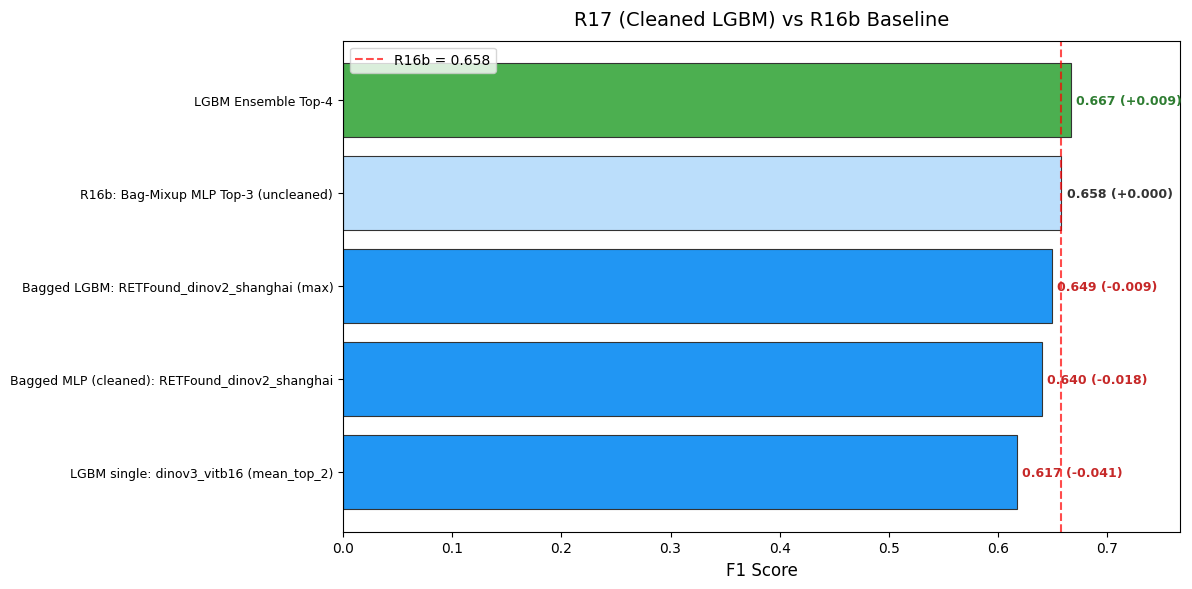


Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\r17_cleaned_lgbm\grand_comparison.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 10 — Grand Comparison: R16b vs R17 variants (LGBM + MLP)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 100)
print("GRAND COMPARISON — R17 (Cleaned LGBM + MLP) vs R16b Baseline")
print("=" * 100)

# Collect best results from each stage
comparison_rows = []

# R16b baseline
comparison_rows.append(dict(
    method="R16b: Bag-Mixup MLP Top-3 (uncleaned)",
    category="baseline",
    f1_score=R16B_F1,
    auc=np.nan,
    delta=0.0,
))

# Best LGBM single model
lgbm_single_best = best_per_emb.iloc[0]
comparison_rows.append(dict(
    method=f"LGBM single: {lgbm_single_best['embedding']} ({lgbm_single_best['agg_method']})",
    category="lgbm_single",
    f1_score=lgbm_single_best['f1_score'],
    auc=lgbm_single_best['auc'],
    delta=lgbm_single_best['f1_score'] - R16B_F1,
))

# Best bagged LGBM
lgbm_bag_best = bag_best.iloc[0]
comparison_rows.append(dict(
    method=f"Bagged LGBM: {lgbm_bag_best['embedding']} ({lgbm_bag_best['agg_method']})",
    category="lgbm_bagged",
    f1_score=lgbm_bag_best['f1_score'],
    auc=lgbm_bag_best['auc'],
    delta=lgbm_bag_best['f1_score'] - R16B_F1,
))

# Best LGBM ensemble
if len(ens_df) > 0:
    lgbm_ens_best = ens_df.iloc[0]
    comparison_rows.append(dict(
        method=f"LGBM Ensemble {lgbm_ens_best['ensemble']}",
        category="lgbm_ensemble",
        f1_score=lgbm_ens_best['f1_score'],
        auc=lgbm_ens_best['auc'],
        delta=lgbm_ens_best['f1_score'] - R16B_F1,
    ))

# Best MLP single (cleaned)
mlp_best = mlp_df.iloc[0]
comparison_rows.append(dict(
    method=f"Bagged MLP (cleaned): {mlp_best['embedding']} ({mlp_best['agg_method']})",
    category="mlp_cleaned",
    f1_score=mlp_best['f1_score'],
    auc=mlp_best['auc'],
    delta=mlp_best['f1_score'] - R16B_F1,
))

# Best MLP ensemble (cleaned)
if len(mlp_ens_df) > 0:
    mlp_ens_best_row = mlp_ens_df.iloc[0]
    comparison_rows.append(dict(
        method=f"MLP Ensemble {mlp_ens_best_row['ensemble']} (cleaned)",
        category="mlp_ensemble",
        f1_score=mlp_ens_best_row['f1_score'],
        auc=mlp_ens_best_row['auc'],
        delta=mlp_ens_best_row['f1_score'] - R16B_F1,
    ))

comp_df = pd.DataFrame(comparison_rows).sort_values('f1_score', ascending=False)

print()
display(comp_df[['method', 'category', 'f1_score', 'auc', 'delta']])

best_overall = comp_df.iloc[0]
print(f"\n*** BEST OVERALL: {best_overall['method']}")
print(f"    F1 = {best_overall['f1_score']:.3f}  (Δ = {best_overall['delta']:+.3f} vs R16b) ***")

# ─── Bar chart comparison ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
methods = comp_df['method'].values
f1s = comp_df['f1_score'].values
color_map = {
    'baseline': '#BBDEFB',
    'lgbm_single': '#2196F3',
    'lgbm_bagged': '#1976D2',
    'lgbm_ensemble': '#4CAF50',
    'mlp_cleaned': '#FF9800',
    'mlp_ensemble': '#F44336',
}
colors = [color_map.get(c, '#999') for c in comp_df['category']]

bars = ax.barh(range(len(methods)), f1s, color=colors, edgecolor='#333', linewidth=0.8)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('R17: LGBM vs MLP Ensembles on Cleaned Data vs R16b Baseline', fontsize=14, pad=12)
ax.axvline(R16B_F1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'R16b = {R16B_F1}')

for bar, f1_val, delta in zip(bars, f1s, comp_df['delta'].values):
    color = '#2E7D32' if delta > 0 else '#C62828' if delta < 0 else '#333'
    ax.text(f1_val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{f1_val:.3f} ({delta:+.3f})', va='center', fontsize=9, color=color, fontweight='bold')

ax.legend(fontsize=10)
ax.set_xlim(0, max(f1s) * 1.15)
ax.invert_yaxis()
plt.tight_layout()

if SAVE_PLOTS:
    fig.savefig(RESULTS_DIR / 'grand_comparison_r17_vs_r16b.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── Save summary ─────────────────────────────────────────────────────────
comp_df.to_csv(RESULTS_DIR / 'grand_comparison.csv', index=False)
print(f"\nSaved: {RESULTS_DIR / 'grand_comparison.csv'}")